In [354]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Market Sentiment Data:")
print(sentiment.head())

print("\nTrader Data:")
print(trades.head())

Market Sentiment Data:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trader Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144

In [355]:
print("Market Sentiment Columns:")
print(sentiment.columns)

print("\nTrader Data Columns:")
print(trades.columns)

print("\nSentiment Shape:", sentiment.shape)
print("Trader Shape:", trades.shape)

Market Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

Trader Data Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

Sentiment Shape: (2644, 4)
Trader Shape: (211224, 16)


In [356]:
print(sentiment.info())

print("\n-------------------\n")

print(trades.info())

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None

-------------------

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  f

In [357]:
print("Market Sentiment Missing Values:")
print(sentiment.isnull().sum())

print("\nTrader Data Missing Values:")
print(trades.isnull().sum())

Market Sentiment Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Data Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [358]:
# Market Sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Trader timestamp
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

# Create common date column
sentiment['Date'] = sentiment['date'].dt.date
trades['Date'] = trades['Timestamp'].dt.date

print("Done")

Done


In [359]:
merged = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN


In [360]:
merged = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN


In [361]:
print(merged['classification'].value_counts())

Series([], Name: count, dtype: int64)


In [362]:
profit_by_market_sentiment = (
    merged.groupby('classification')['Closed PnL']
    .mean()
    .sort_values(ascending=False)
)

print(profit_by_market_sentiment)

Series([], Name: Closed PnL, dtype: float64)


In [363]:
merged['Win'] = merged['Closed PnL'] > 0

win_rate = (
    merged.groupby('classification')['Win']
    .mean() * 100
)

print(win_rate)

Series([], Name: Win, dtype: float64)


In [364]:
print("Missing classifications:")
print(merged['classification'].isna().sum())

print("\nTotal rows:")
print(len(merged))

Missing classifications:
211224

Total rows:
211224


In [365]:
print("Missing classifications:")
print(merged['classification'].isna().sum())

print("\nTotal rows:")
print(len(merged))

Missing classifications:
211224

Total rows:
211224


In [366]:
print("Trader Data Date Range:")
print(trades['Date'].min())
print(trades['Date'].max())

print("\nMarket Sentiment Data Date Range:")
print(sentiment['Date'].min())
print(sentiment['Date'].max())

Trader Data Date Range:
1970-01-01
1970-01-01

Market Sentiment Data Date Range:
2018-02-01
2025-05-02


In [367]:
print(trades['Timestamp'].head(10))

0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
5   1970-01-01 00:28:50
6   1970-01-01 00:28:50
7   1970-01-01 00:28:50
8   1970-01-01 00:28:50
9   1970-01-01 00:28:50
Name: Timestamp, dtype: datetime64[ns]


In [368]:
print(trades[['Timestamp', 'Timestamp IST']].head(10))

            Timestamp     Timestamp IST
0 1970-01-01 00:28:50  02-12-2024 22:50
1 1970-01-01 00:28:50  02-12-2024 22:50
2 1970-01-01 00:28:50  02-12-2024 22:50
3 1970-01-01 00:28:50  02-12-2024 22:50
4 1970-01-01 00:28:50  02-12-2024 22:50
5 1970-01-01 00:28:50  02-12-2024 22:50
6 1970-01-01 00:28:50  02-12-2024 22:50
7 1970-01-01 00:28:50  02-12-2024 22:50
8 1970-01-01 00:28:50  02-12-2024 22:50
9 1970-01-01 00:28:50  02-12-2024 22:50


In [369]:
# Convert Trader Data timestamp correctly

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['Date'] = trades['Timestamp IST'].dt.date

# Check range
print("Trader Data Date Range:")
print(trades['Date'].min())
print(trades['Date'].max())

Trader Data Date Range:
2023-05-01
2025-05-01


In [370]:
merged = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

print("Merged Shape:", merged.shape)

print("\nMissing classifications:")
print(merged['classification'].isna().sum())

Merged Shape: (211224, 18)

Missing classifications:
6


In [371]:
print(merged['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [372]:
profit_by_market_sentiment = (
    merged.groupby('classification')['Closed PnL']
    .mean()
    .sort_values(ascending=False)
)

print(profit_by_market_sentiment)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [373]:
merged['Win'] = merged['Closed PnL'] > 0

win_rate = (
    merged.groupby('classification')['Win']
    .mean() * 100
)

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


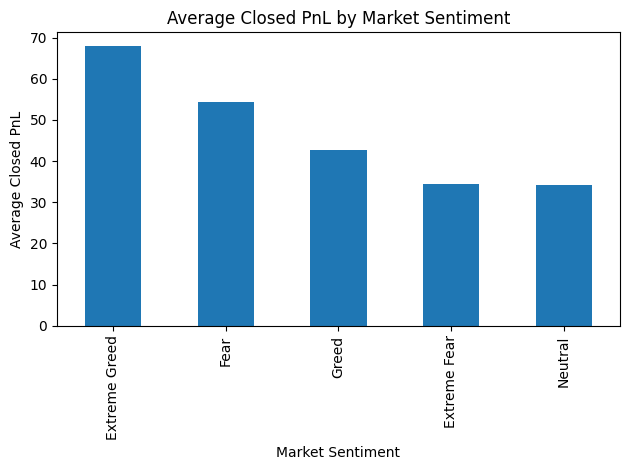

In [374]:
import matplotlib.pyplot as plt

profit_by_market_sentiment.plot(kind='bar')

plt.title('Average Closed PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')

plt.tight_layout()
plt.show()

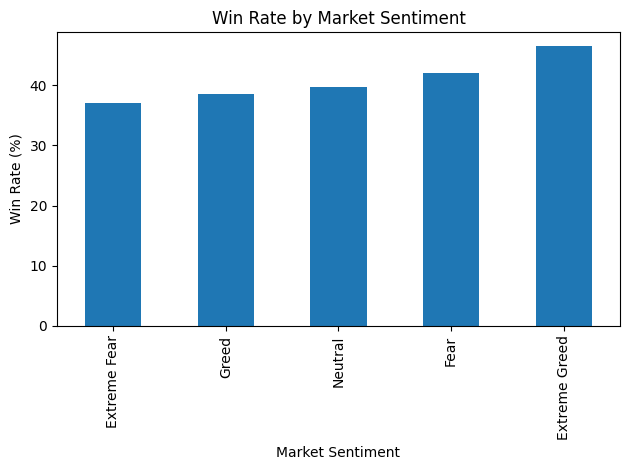

In [375]:
win_rate.sort_values().plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')

plt.tight_layout()
plt.show()

In [376]:
trade_size = (
    merged.groupby('classification')['Size USD']
    .mean()
    .sort_values(ascending=False)
)

print(trade_size)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


In [377]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

print(top_traders.head(10))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


In [378]:
coin_profit = (
    merged.groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

print(coin_profit.head(10))

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


In [379]:
direction_profit = (
    merged.groupby('Direction')['Closed PnL']
    .mean()
)

print(direction_profit)

Direction
Auto-Deleveraging             7184.807003
Buy                              0.000000
Close Long                      74.426422
Close Short                    103.012804
Liquidated Isolated Short   -12752.913040
Long > Short                    34.936474
Open Long                        0.000000
Open Short                       0.000000
Sell                           146.053081
Settlement                     -29.215368
Short > Long                   154.190415
Spot Dust Conversion             0.000000
Name: Closed PnL, dtype: float64


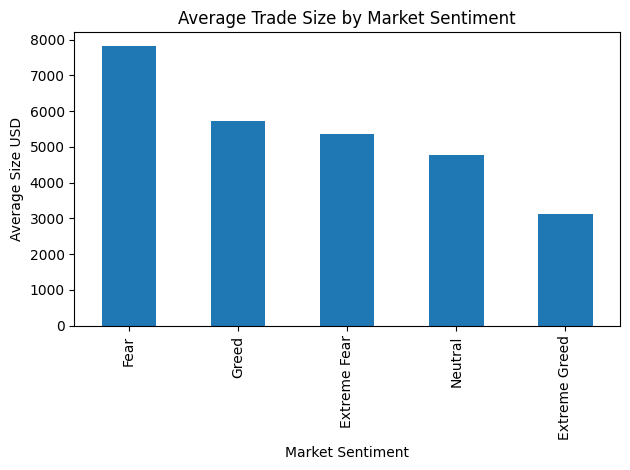

In [380]:
trade_size.plot(kind='bar')
plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Size USD')
plt.tight_layout()
plt.show()

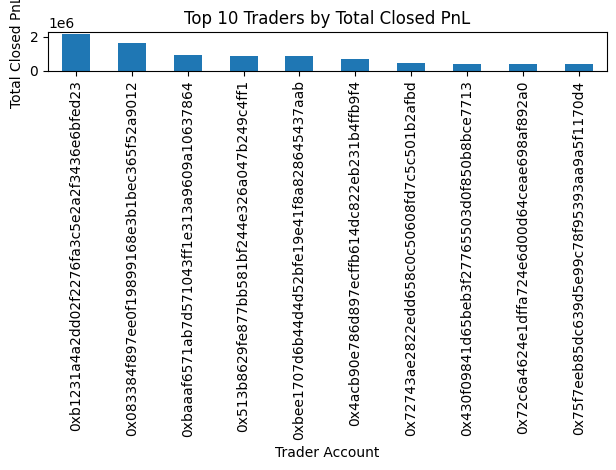

In [381]:
top_traders.head(10).plot(kind='bar')

plt.title('Top 10 Traders by Total Closed PnL')
plt.xlabel('Trader Account')
plt.ylabel('Total Closed PnL')

plt.tight_layout()
plt.show()

In [382]:
trade_size = (
    merged.groupby('classification')['Size USD']
    .mean()
    .sort_values(ascending=False)
)

print(trade_size)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


In [383]:
coin_profit = (
    merged.groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

print(coin_profit.head(10))

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


In [385]:
direction_profit = (
    merged.groupby('Direction')['Closed PnL']
    .mean()
)

print(direction_profit)

Direction
Auto-Deleveraging             7184.807003
Buy                              0.000000
Close Long                      74.426422
Close Short                    103.012804
Liquidated Isolated Short   -12752.913040
Long > Short                    34.936474
Open Long                        0.000000
Open Short                       0.000000
Sell                           146.053081
Settlement                     -29.215368
Short > Long                   154.190415
Spot Dust Conversion             0.000000
Name: Closed PnL, dtype: float64
